In [35]:
# 📦 Schritt 1: Bibliotheken importieren
import pandas as pd
import glob
import os

# 📁 Schritt 2: Pfad zu den Metrics-Dateien definieren
folder_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solution_PSA_DbSA_400/"
file_pattern = os.path.join(folder_path, "Metrics_*.csv")

# 📂 Schritt 3: Alle passenden CSV-Dateien finden
file_list = glob.glob(file_pattern)
print(f"{len(file_list)} Dateien gefunden.")

# 📊 Schritt 4: Alle Dateien einlesen und zusammenfügen
all_dfs = [pd.read_csv(file) for file in file_list]
full_df = pd.concat(all_dfs, ignore_index=True)
print("Daten erfolgreich zusammengeführt.")
display(full_df.head())

# 📈 Schritt 5: Durchschnittswerte pro Instanz + Algorithmus berechnen
average_df = full_df.groupby(["Instance", "Algorithm"], as_index=False).mean()
print("Durchschnittswerte berechnet.")
display(average_df.head())

# 💾 Schritt 6: Ergebnis abspeichern
output_path = os.path.join(folder_path, "Metrics_averaged.csv")
average_df.to_csv(output_path, index=False)
print(f"Aggregierte Datei gespeichert unter: {output_path}")

5 Dateien gefunden.
Daten erfolgreich zusammengeführt.


,Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
0,a3_o80_m10_an10_ar9_reduced,PSA,258.71,0.134409,0.663473,0.226489,0.400047,3.763441,0.199512,0.597446
1,a3_o80_m10_an10_ar9_reduced,DBSA,239.22,0.922043,0.172577,0.459592,0.047414,96.236559,0.049898,0.628811
2,a5_o96_m10_an10_ar10_reduced,PSA,192.47,0.568966,0.256008,0.190111,0.172291,27.083333,0.089349,0.620371
3,a5_o96_m10_an10_ar10_reduced,DBSA,182.44,0.833333,0.246802,0.219659,0.111660,72.916667,0.097774,0.660981
4,a10_o107_m5_an57_ar12,PSA,154.99,0.201389,1.106847,0.571459,0.094390,11.764706,0.087045,0.424270


Durchschnittswerte berechnet.


,Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
0,a10_o107_m5_an57_ar12,DBSA,163.4975,0.891486,0.166202,0.432888,0.232850,85.324939,0.044942,0.614184
1,a10_o107_m5_an57_ar12,PSA,162.7800,0.308779,0.867617,0.291130,0.237240,14.675061,0.087987,0.521798
2,a10_o114_m6_an57_ar11,DBSA,290.8775,0.926984,0.164442,0.458592,0.071113,85.614388,0.066837,0.849338
3,a10_o114_m6_an57_ar11,PSA,310.7075,0.323372,0.885862,0.438581,0.176664,14.385612,0.148349,0.818528
4,a10_o128_m6_an51_ar13,DBSA,228.8425,0.899588,0.226482,0.007199,0.176794,88.443248,0.059926,0.894628


Aggregierte Datei gespeichert unter: /Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solution_PSA_DbSA_400/Metrics_averaged.csv


In [36]:
import pandas as pd

# Datei einlesen (Pfad ggf. anpassen, falls Datei woanders liegt)
df = pd.read_csv("Metrics_averaged.csv")

# Rundung zur besseren Lesbarkeit (optional)
df_rounded = df.round(3)

# Ausgabe als DataFrame mit schöner Formatierung
from IPython.display import display, HTML
display(HTML(df_rounded.to_html(index=False)))

Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
a10_o107_m5_an57_ar12,DBSA,163.498,0.891,0.166,0.433,0.233,85.325,0.045,0.614
a10_o107_m5_an57_ar12,PSA,162.780,0.309,0.868,0.291,0.237,14.675,0.088,0.522
a10_o114_m6_an57_ar11,DBSA,290.878,0.927,0.164,0.459,0.071,85.614,0.067,0.849
a10_o114_m6_an57_ar11,PSA,310.708,0.323,0.886,0.439,0.177,14.386,0.148,0.819
a10_o128_m6_an51_ar13,DBSA,228.843,0.900,0.226,0.007,0.177,88.443,0.060,0.895
a10_o128_m6_an51_ar13,PSA,244.003,0.187,0.795,0.007,0.171,11.557,0.159,0.913
a10_o144_m6_an53_ar12,DBSA,153.957,0.768,0.235,0.503,0.208,63.568,0.064,0.577
a10_o144_m6_an53_ar12,PSA,167.980,0.657,0.309,0.495,0.154,36.432,0.109,0.629
a15_o170_m9_an80_ar18,DBSA,444.782,0.851,0.107,0.096,0.186,81.384,0.034,0.782
a15_o170_m9_an80_ar18,PSA,399.750,0.398,0.255,0.135,0.176,18.616,0.057,0.891


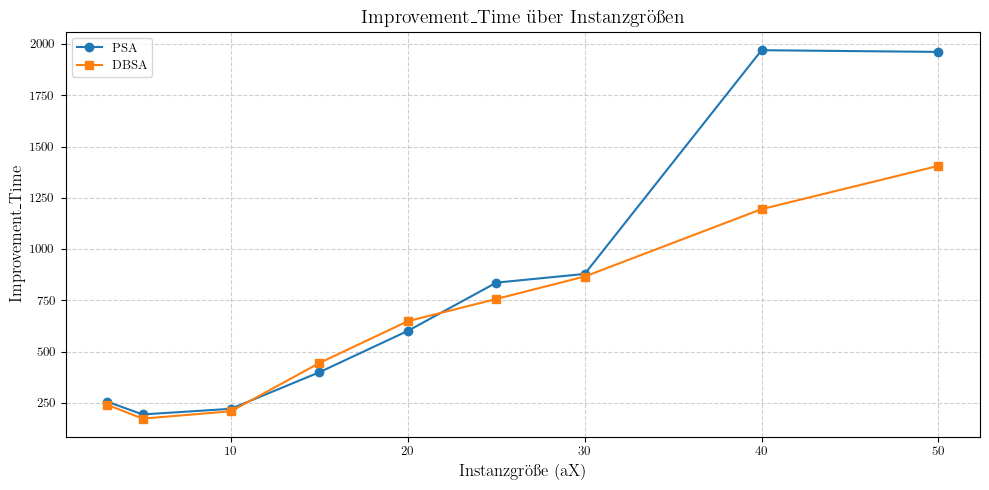

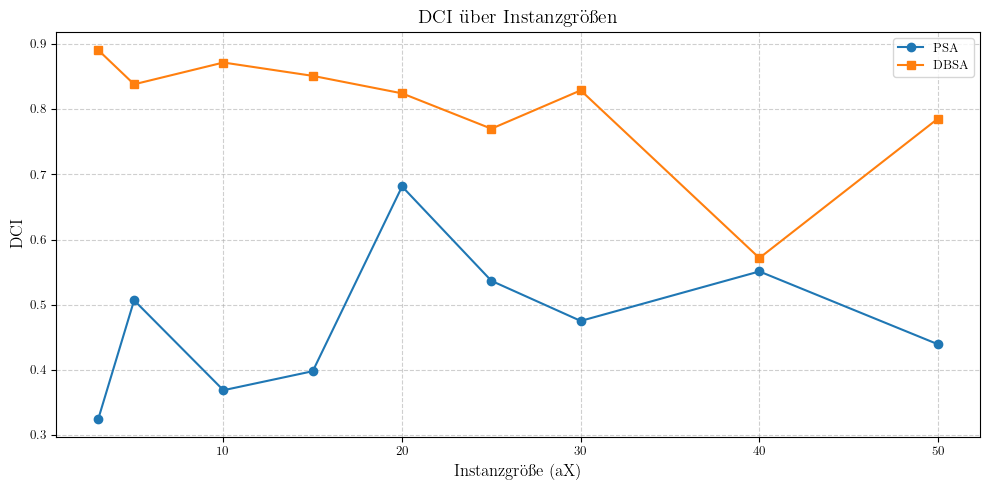

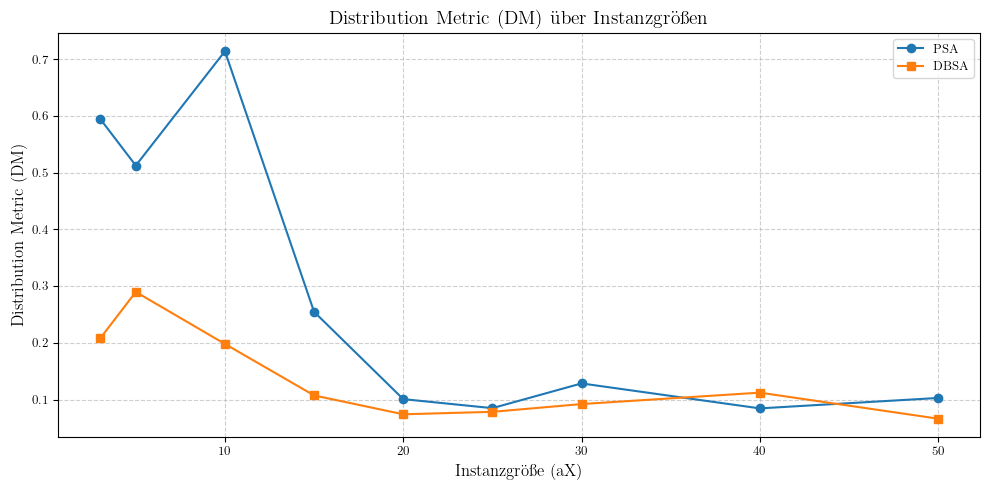

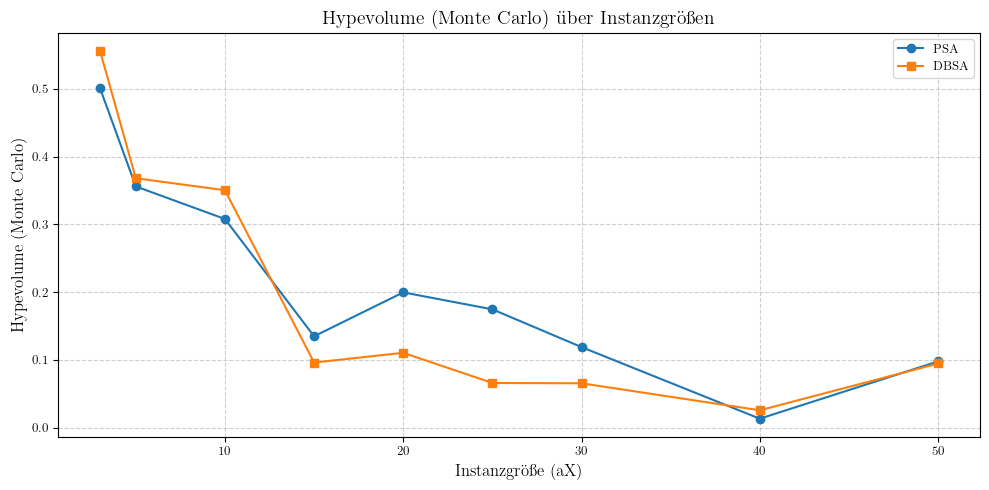

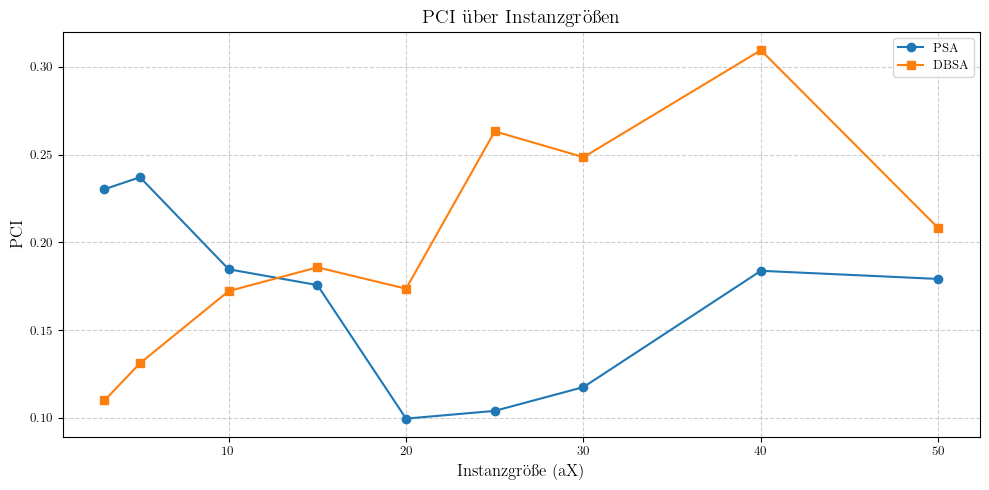

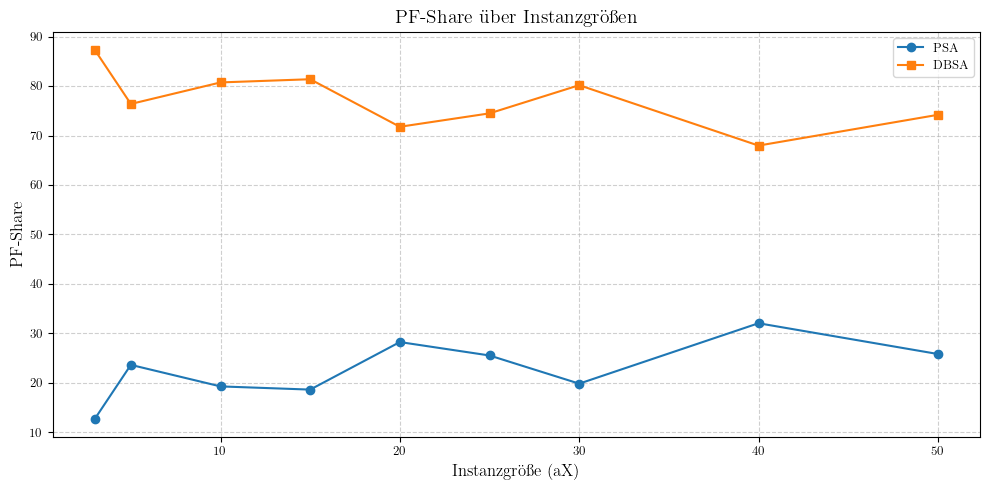

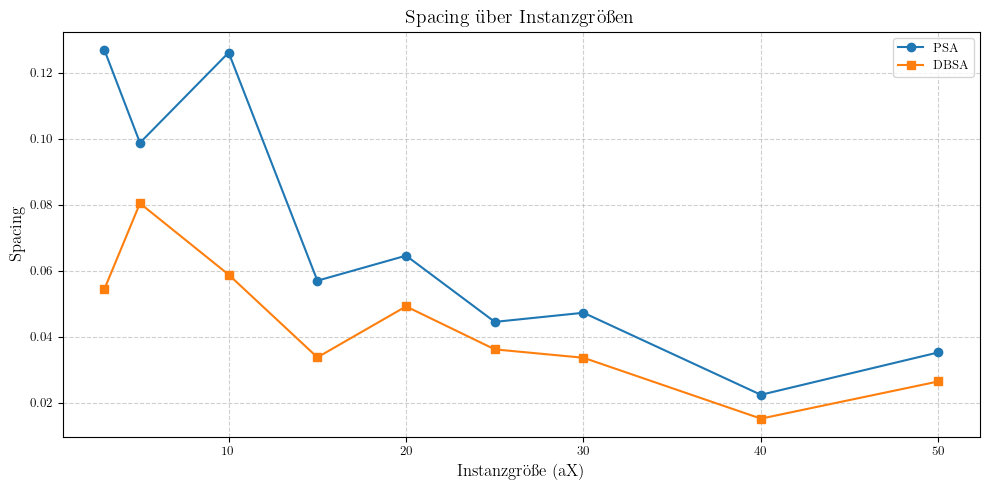

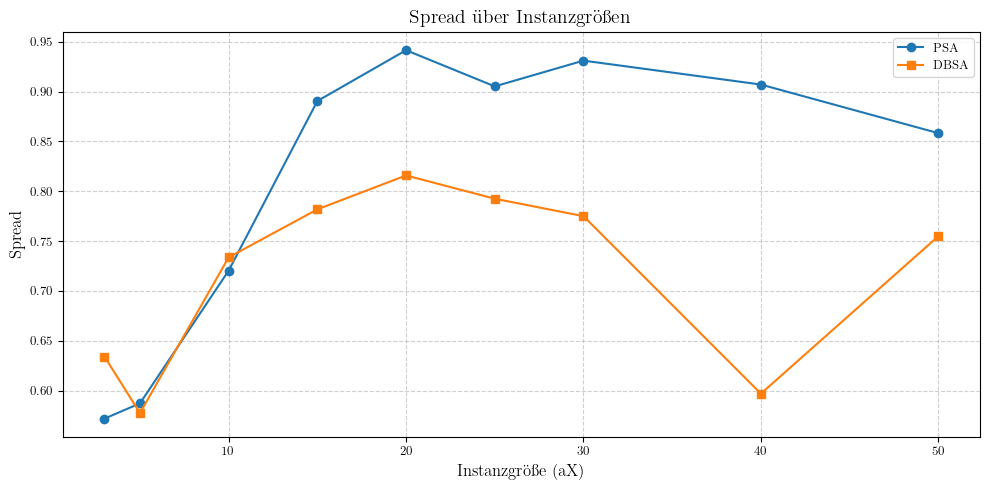

In [37]:
# 📦 Imports
import pandas as pd
import matplotlib.pyplot as plt

# 📂 Datei einlesen
file_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solution_PSA_DbSA_400/Metrics_averaged.csv"
df = pd.read_csv(file_path)

# 🔍 Instanzgröße extrahieren (z. B. 'a3_o80' → 3)
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🧹 Metriken auswählen (alle außer 'Instance', 'Algorithm', 'Instance_Size')
metrics = [col for col in df.columns if col not in ["Instance", "Algorithm", "Instance_Size"]]

# 🧮 Mittelwert pro (Instance_Size, Algorithm)
agg_df = df.groupby(["Instance_Size", "Algorithm"], as_index=False)[metrics].mean()

# 📊 Sortieren nach Instanzgröße
agg_df = agg_df.sort_values("Instance_Size")

# 🎨 Visualisierung: Jede Metrik als eigenes Diagramm
for metric in metrics:
    plt.figure(figsize=(10, 5))

    # PSA-Linie
    psa_data = agg_df[agg_df["Algorithm"] == "PSA"]
    plt.plot(psa_data["Instance_Size"], psa_data[metric], marker="o", label="PSA")

    # DBSA-Linie
    dbsa_data = agg_df[agg_df["Algorithm"] == "DBSA"]
    plt.plot(dbsa_data["Instance_Size"], dbsa_data[metric], marker="s", label="DBSA")

    # ✨ Formatierung
    plt.title(f"{metric} über Instanzgrößen", fontsize=14)
    plt.xlabel("Instanzgröße (aX)", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [38]:
# Durchschnittswerte je Algorithmus
df.groupby("Algorithm").mean(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread,Instance_Size
Algorithm,,,,,,,,,
DBSA,547.444,0.821,0.152,0.232,0.193,78.046,0.047,0.722,19.0
PSA,665.272,0.449,0.393,0.236,0.172,21.954,0.083,0.790,19.0


In [39]:
# Standardabweichungen je Algorithmus
df.groupby("Algorithm").std(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread,Instance_Size
Algorithm,,,,,,,,,
DBSA,429.118,0.094,0.074,0.211,0.067,7.977,0.019,0.114,14.623
PSA,655.261,0.148,0.322,0.177,0.048,7.977,0.045,0.161,14.623


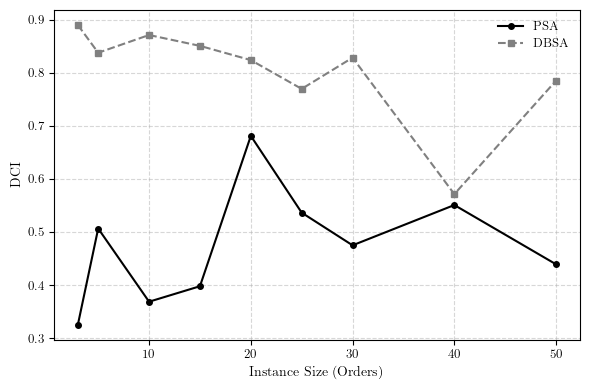

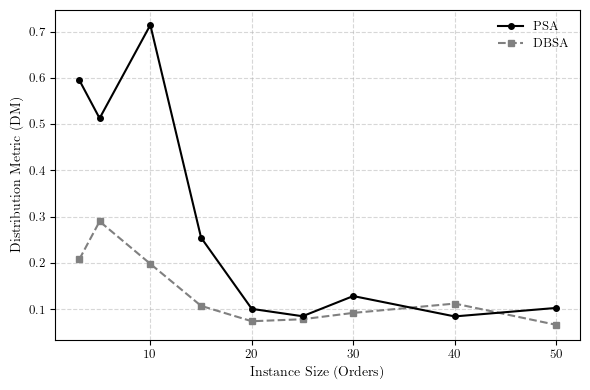

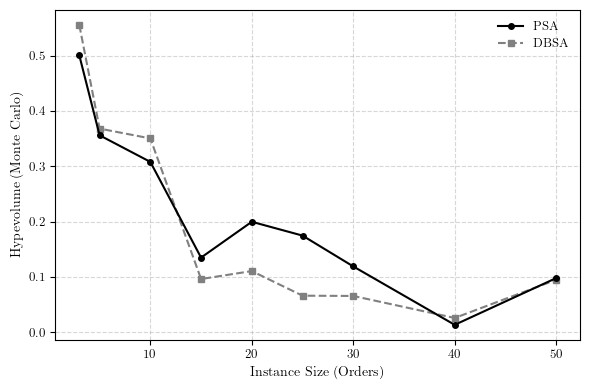

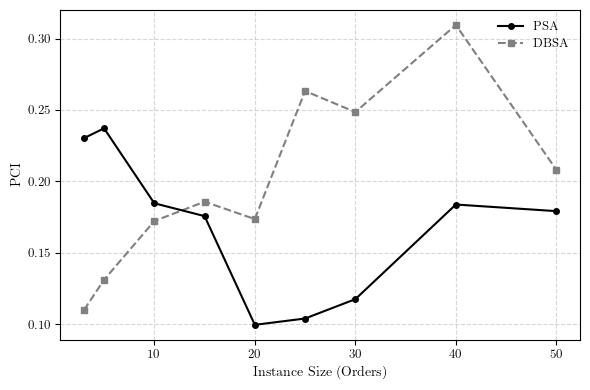

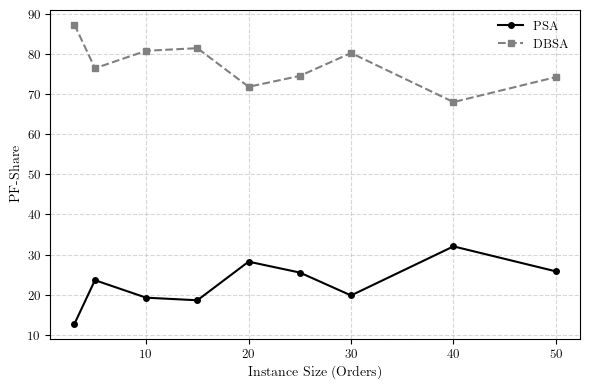

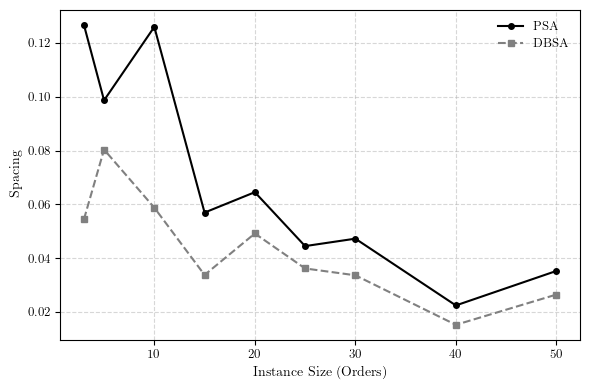

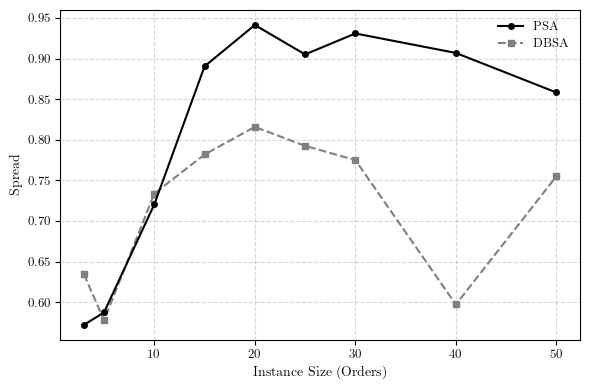

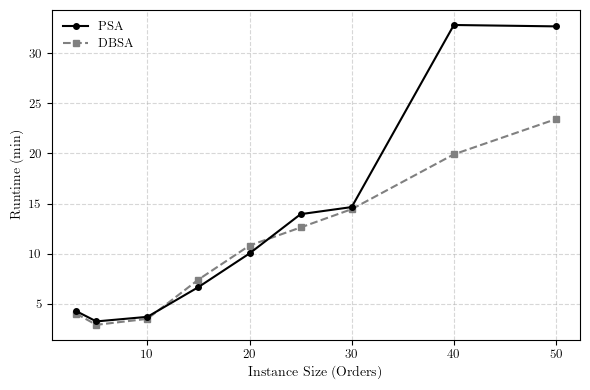

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 🎨 LaTeX-Stil global aktivieren
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12
})

# 📂 CSV einlesen
df = pd.read_csv("Metrics_averaged.csv")

# ⏱️ Wenn "Improvement Time" vorhanden ist, umbenennen und in Minuten umrechnen
if "Improvement_Time" in df.columns:
    df["Runtime (min)"] = df["Improvement_Time"] / 60
    df.drop(columns=["Improvement_Time"], inplace=True)

# 📊 Instanzgröße extrahieren
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🔎 Alle Metriken außer diesen:
metrics = [col for col in df.columns if col not in ["Instance", "Algorithm", "Instance_Size"]]

# 🧮 Durchschnitt berechnen
agg_df = df.groupby(["Instance_Size", "Algorithm"], as_index=False)[metrics].mean()
agg_df = agg_df.sort_values("Instance_Size")

# 🎨 Farb-/Stilzuordnung
style_map = {
    "PSA": {"label": "PSA", "linestyle": "-", "color": "black", "marker": "o", "zorder": 3},
    "DBSA": {"label": "DBSA", "linestyle": "--", "color": "gray", "marker": "s", "zorder": 2},
}

# 📊 Plot für jede Metrik
for metric in metrics:
    plt.figure(figsize=(6, 4))

    for algo, style in style_map.items():
        subset = agg_df[agg_df["Algorithm"] == algo]
        plt.plot(
            subset["Instance_Size"], subset[metric],
            label=style["label"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            color=style["color"],
            markersize=4,
            linewidth=1.5,
            zorder=style["zorder"]
        )

    # 📏 Formatierung
    #plt.title(metric)
    plt.xlabel("Instance Size (Orders)")
    plt.ylabel(metric)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="best", frameon=False)
    plt.tight_layout()

    # Optional: Speichern als PDF
    #plt.savefig(f"{metric.replace(' ', '_').lower()}_lineplot.pdf", dpi=300, bbox_inches="tight")

    plt.show()

<Figure size 600x400 with 0 Axes>

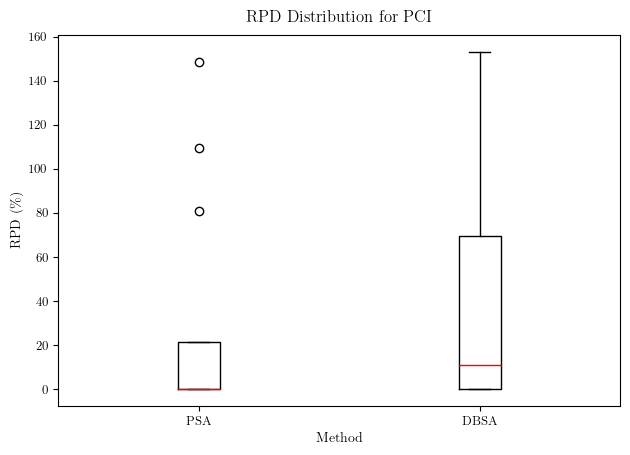

<Figure size 600x400 with 0 Axes>

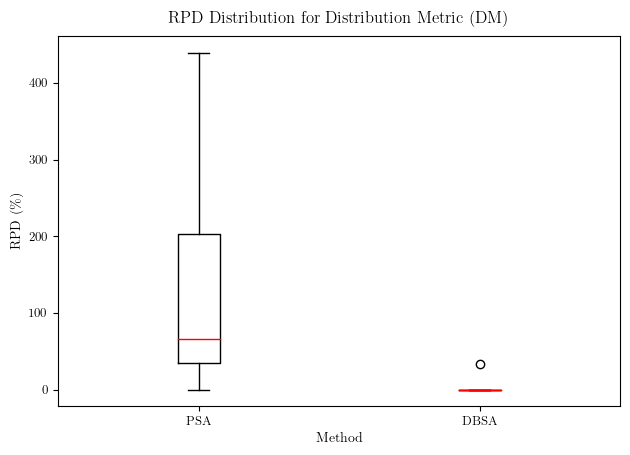

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 📐 Stil: LaTeX-kompatible Darstellung für Publikationen
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12
})

# 📂 CSV einlesen
df = pd.read_csv("Metrics_averaged.csv")

# 📊 Instanzgröße extrahieren (optional für spätere Analysen)
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🎯 Zielname
for objective in ["PCI", "Distribution Metric (DM)"]:
    # 🧮 RPD berechnen (Minimierungsproblem!)
    df["Best Value"] = df.groupby("Instance")[objective].transform("min")
    df[f"{objective} RPD"] = ((df[objective] - df["Best Value"]) / df["Best Value"]) * 100

    # 🧼 Methoden sortieren
    df["Algorithm"] = pd.Categorical(df["Algorithm"], categories=["PSA", "DBSA"], ordered=True)

    # 📦 Boxplot zeichnen
    plt.figure(figsize=(6, 4))
    df.boxplot(
        column=f"{objective} RPD",
        by="Algorithm",
        grid=False,
        showfliers=True,
        boxprops=dict(color="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="red"),
    )

    # 🖼️ Achsen und Layout
    plt.title(f"RPD Distribution for {objective}", fontsize=12, pad=10)
    plt.suptitle("")
    plt.xlabel("Method")
    plt.ylabel("RPD (\%)")
    plt.tight_layout()

    # 💾 Optional: als PDF speichern
    #plt.savefig(f"rpd_boxplot_{objective.lower().replace(' ', '_')}.pdf", format="pdf", bbox_inches="tight", dpi=300)
    plt.show()

<Figure size 600x400 with 0 Axes>

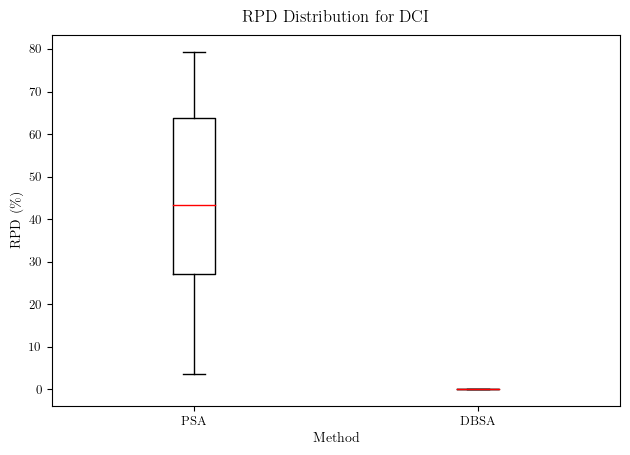

<Figure size 600x400 with 0 Axes>

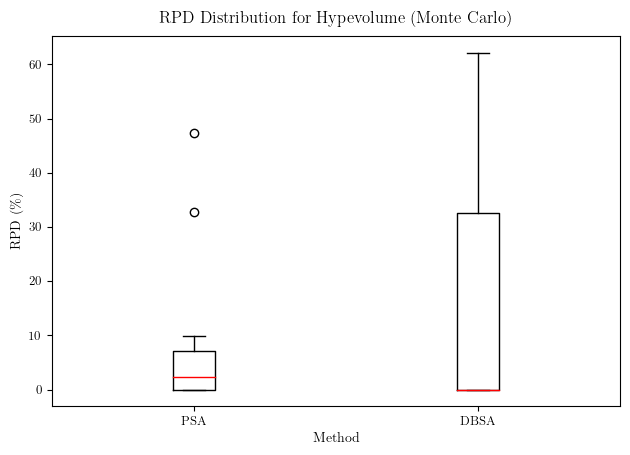

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 📐 Stil: LaTeX-kompatible Darstellung für Publikationen
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12
})

# 📂 CSV einlesen
df = pd.read_csv("Metrics_averaged.csv")

# 📊 Instanzgröße extrahieren (optional für spätere Analysen)
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🎯 Zielname
for objective in ["DCI", "Hypevolume (Monte Carlo)"]:
    # 🧮 RPD berechnen (Maximierungsproblem!)
    df["Best Value"] = df.groupby("Instance")[objective].transform("max")
    df[f"{objective} RPD"] = ((df["Best Value"] - df[objective]) / df["Best Value"]) * 100

    # 🧼 Methoden sortieren
    df["Algorithm"] = pd.Categorical(df["Algorithm"], categories=["PSA", "DBSA"], ordered=True)

    # 📦 Boxplot zeichnen
    plt.figure(figsize=(6, 4))
    df.boxplot(
        column=f"{objective} RPD",
        by="Algorithm",
        grid=False,
        showfliers=True,
        boxprops=dict(color="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="red"),
    )

    # 🖼️ Achsen und Layout
    plt.title(f"RPD Distribution for {objective}", fontsize=12, pad=10)
    plt.suptitle("")
    plt.xlabel("Method")
    plt.ylabel("RPD (\%)")
    plt.tight_layout()

    # 💾 Optional: als PDF speichern
    #plt.savefig(f"rpd_boxplot_{objective.lower().replace(' ', '_')}.pdf", format="pdf", bbox_inches="tight", dpi=300)
    plt.show()

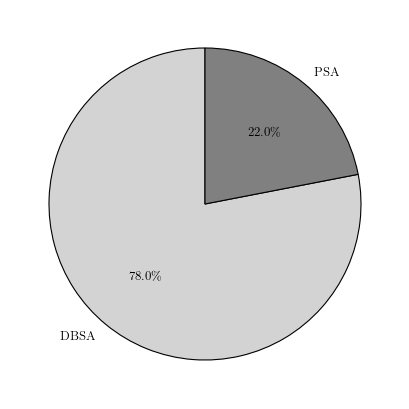

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 🎨 LaTeX-Stil aktivieren
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12
})

# 📂 CSV einlesen
df = pd.read_csv("Metrics_averaged.csv")

# 📊 Durchschnittlicher PF-Share je Algorithmus
pf_share_avg = df.groupby("Algorithm")["PF-Share"].mean()

# 📋 Labels mit Prozentangabe
labels = [f"{alg}" for alg in pf_share_avg.index]
colors = ["lightgray", "gray"]

# 🥧 Kreisdiagramm mit schwarzem Rand
fig, ax = plt.subplots(figsize=(4.8, 4.2))
wedges, texts, autotexts = ax.pie(
    pf_share_avg,
    labels=labels,
    colors=colors,
    startangle=90,
    autopct="%1.1f\\%%",
    textprops={"fontsize": 9},
    wedgeprops={"edgecolor": "black", "linewidth": 0.8}  # 🔲 schwarzer Rand
)

# 🖼️ Titel
#ax.set_title("Average PF-Share per Algorithm", fontsize=12)

# 💾 Optional speichern
#plt.savefig("pf_share_piechart_blackedge.pdf", bbox_inches="tight", dpi=300)

plt.tight_layout()
plt.show()